In [1]:


import time
import requests
import pandas as pd
import sys
from datetime import datetime



# ---------------------------
#  API CONFIG & SAFE GET (RETRY + BACKOFF)
# ---------------------------

In [2]:

import json

# Load secrets
with open("../secrets.json", "r") as f:
    secrets = json.load(f)

API_KEY = secrets["API_KEY"]
HEADERS = {"X-API-Key": API_KEY}

print("API key loaded")

BASE_URL = "https://api.openaq.org/v3"


# ---------------------------
#  SAFE GET (RETRY + BACKOFF)
# ---------------------------
def safe_get(url, params=None, max_retries=3):
    for attempt in range(1, max_retries + 1):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=30)
            r.raise_for_status()
            return r.json()
        except Exception as e:
            print(f"[Attempt {attempt}/{max_retries}] Error → {e}")
            time.sleep(2)
    raise RuntimeError(f"Failed after {max_retries} attempts")

API key loaded


# ---------------------------
#  GET LOCATIONS WITH PM2.5
# ---------------------------

In [3]:

def get_city_locations(country_id, city):
    params = {
        "countries_id": country_id,
        "city": city,
        "parameters_id": 2,  # PM2.5
        "limit": 200
    }
    data = safe_get(f"{BASE_URL}/locations", params)
    return data.get("results", [])


milan_locations = get_city_locations(91, "Milan")
paris_locations = get_city_locations(22, "Paris")

print("Milan locations:", len(milan_locations))
print("Paris locations:", len(paris_locations))


Milan locations: 200
Paris locations: 200


# ---------------------------
#  EXTRACT PM2.5 SENSOR IDS
# ---------------------------

In [4]:

def extract_pm25_sensors(locations):
    sensors = []
    for loc in locations:
        for sensor in loc.get("sensors", []):
            param = sensor.get("parameter", {})
            if param.get("name") == "pm25":
                sensors.append({
                    "id": sensor["id"],
                    "location": loc.get("name")
                })
    return sensors


milan_sensors = extract_pm25_sensors(milan_locations)
paris_sensors = extract_pm25_sensors(paris_locations)

print("Milan PM2.5 sensors:", len(milan_sensors))
print("Paris PM2.5 sensors:", len(paris_sensors))


Milan PM2.5 sensors: 200
Paris PM2.5 sensors: 200


# ---------------------------
#  DOWNLOAD DAILY DATA (2024)
# ---------------------------

In [5]:


def get_sensor_days(sensor_id):
    url = f"{BASE_URL}/sensors/{sensor_id}/days"
    params = {
        "datetime_from": "2024-01-01T00:00:00Z",
        "datetime_to": "2024-12-31T23:59:59Z",
        "limit": 365
    }

    while True:
        r = requests.get(url, params=params, headers=HEADERS, timeout=30)

        if r.status_code == 429:
            print(f"Sensor {sensor_id}: rate-limited, waiting...")
            time.sleep(3)
            continue

        r.raise_for_status()
        return r.json().get("results", [])


def download_city_days(sensor_list, city):
    rows = []

    for i, sensor in enumerate(sensor_list, start=1):
        sensor_id = sensor["id"]
        print(f"{city}: Sensor {sensor_id} ({i}/{len(sensor_list)})")

        for item in get_sensor_days(sensor_id):
            period = item.get("period", {})
            dt = period.get("datetimeFrom", {}).get("utc")

            if not dt:
                continue

            rows.append({
                "datetime": dt,
                "value": item.get("average") or item.get("value"),
                "unit": item.get("unit"),
                "sensor_id": sensor_id,
                "city": city
            })

    df = pd.DataFrame(rows)
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)

    # Hard filter for 2024 safety
    df = df[(df["datetime"] >= "2024-01-01") & (df["datetime"] <= "2024-12-31")]

    # Clean data
    df = df.sort_values("datetime").drop_duplicates()

    return df





# ---------------------------
#  RUN PIPELINE
# -----------------------

In [6]:

df_milan = download_city_days(milan_sensors, "Milan")
df_paris = download_city_days(paris_sensors, "Paris")

print("\n--- FINAL ROW COUNTS ---")
print("Milan rows:", len(df_milan))
print("Paris rows:", len(df_paris))

df_milan.head(), df_paris.head()

Milan: Sensor 22134 (1/200)
Milan: Sensor 21765 (2/200)
Milan: Sensor 21773 (3/200)
Milan: Sensor 21768 (4/200)
Milan: Sensor 5079445 (5/200)
Milan: Sensor 1561965 (6/200)
Milan: Sensor 21802 (7/200)
Milan: Sensor 21806 (8/200)
Milan: Sensor 21846 (9/200)
Milan: Sensor 6625728 (10/200)
Milan: Sensor 21813 (11/200)
Milan: Sensor 21830 (12/200)
Milan: Sensor 21819 (13/200)
Milan: Sensor 21841 (14/200)
Milan: Sensor 21823 (15/200)
Milan: Sensor 21824 (16/200)
Milan: Sensor 21827 (17/200)
Milan: Sensor 21829 (18/200)
Milan: Sensor 21833 (19/200)
Milan: Sensor 21836 (20/200)
Milan: Sensor 6629241 (21/200)
Milan: Sensor 21839 (22/200)
Milan: Sensor 21842 (23/200)
Milan: Sensor 5079452 (24/200)
Milan: Sensor 7490833 (25/200)
Milan: Sensor 21850 (26/200)
Milan: Sensor 5079458 (27/200)
Milan: Sensor 21857 (28/200)
Milan: Sensor 21861 (29/200)
Milan: Sensor 22166 (30/200)
Milan: Sensor 22173 (31/200)
Milan: Sensor 22060 (32/200)
Milan: Sensor 22105 (33/200)
Milan: Sensor 22068 (34/200)
Milan: Se

(                       datetime  value  unit  sensor_id   city
 1350  2024-01-01 23:00:00+00:00    7.0  None    5079445  Milan
 9402  2024-01-01 23:00:00+00:00   11.0  None    5079458  Milan
 8295  2024-01-01 23:00:00+00:00   12.0  None    5079452  Milan
 43775 2024-01-01 23:00:00+00:00   11.8  None    7336787  Milan
 7126  2024-01-01 23:00:00+00:00   14.0  None    6629241  Milan,
                        datetime  value  unit  sensor_id   city
 53191 2024-01-01 20:00:00+00:00   5.14  None    7480205  Paris
 2424  2024-01-01 23:00:00+00:00   1.04  None    5078386  Paris
 25380 2024-01-01 23:00:00+00:00  10.90  None    5078968  Paris
 27790 2024-01-01 23:00:00+00:00   2.14  None    5078532  Paris
 64166 2024-01-01 23:00:00+00:00   2.58  None    5078993  Paris)

STEP 1 — Ensure a Proper “date” Column

In [ ]:
df_milan["date"] = df_milan["datetime"].dt.date
df_paris["date"] = df_paris["datetime"].dt.date


STEP 2 — Count Coverage per Sensor (Number of Days)

In [ ]:
milan_coverage = (
    df_milan
    .groupby("sensor_id")["date"]
    .nunique()
    .reset_index(name="days_covered")
    .sort_values("days_covered", ascending=False)
)

milan_coverage


,sensor_id,days_covered
28,7490833,332
75,7777172,330
58,7774679,320
36,7773114,319
29,7531551,318
...,...,...
10,5078279,140
22,5079452,138
23,5079458,126
83,9323263,108


In [ ]:
paris_coverage = (
    df_paris
    .groupby("sensor_id")["date"]
    .nunique()
    .reset_index(name="days_covered")
    .sort_values("days_covered", ascending=False)
)

paris_coverage


,sensor_id,days_covered
25,7480205,333
23,7480203,332
21,7480201,331
27,7798262,318
28,9014237,236
20,6571255,226
19,6571043,193
8,5078301,152
10,5078410,151
29,10182727,146


STEP 3 — Select Sensors With MAXIMUM Coverage

In [ ]:
max_milan_days = milan_coverage["days_covered"].max()

best_milan_sensors = milan_coverage[
    milan_coverage["days_covered"] == max_milan_days
]["sensor_id"].tolist()

max_milan_days, best_milan_sensors


(332, [7490833])

In [ ]:
max_paris_days = paris_coverage["days_covered"].max()

best_paris_sensors = paris_coverage[
    paris_coverage["days_covered"] == max_paris_days
]["sensor_id"].tolist()

max_paris_days, best_paris_sensors


(333, [7480205])

STEP 4 — Filter the Data to Only Best Sensor

In [ ]:
df_milan_best = df_milan[df_milan["sensor_id"].isin(best_milan_sensors)]
df_paris_best = df_paris[df_paris["sensor_id"].isin(best_paris_sensors)]


STEP 5 — Final Combined Dataset (READY FOR ANALYSIS

In [ ]:
df_final = pd.concat([df_milan_best, df_paris_best], ignore_index=True)
df_final = df_final.sort_values(["city", "datetime"]).reset_index(drop=True)

df_final.head(), df_final.tail()


(                   datetime  value  unit  sensor_id   city        date
 0 2024-01-01 23:00:00+00:00    9.0  None    7490833  Milan  2024-01-01
 1 2024-01-02 23:00:00+00:00    6.0  None    7490833  Milan  2024-01-02
 2 2024-01-03 23:00:00+00:00   10.0  None    7490833  Milan  2024-01-03
 3 2024-01-04 23:00:00+00:00    9.0  None    7490833  Milan  2024-01-04
 4 2024-01-05 23:00:00+00:00    7.0  None    7490833  Milan  2024-01-05,
                      datetime  value  unit  sensor_id   city        date
 660 2024-12-19 20:00:00+00:00   4.93  None    7480205  Paris  2024-12-19
 661 2024-12-20 20:00:00+00:00   5.11  None    7480205  Paris  2024-12-20
 662 2024-12-21 20:00:00+00:00   5.20  None    7480205  Paris  2024-12-21
 663 2024-12-22 20:00:00+00:00   3.57  None    7480205  Paris  2024-12-22
 664 2024-12-23 20:00:00+00:00   4.28  None    7480205  Paris  2024-12-23)

Aggregate df_final to City-Level Daily Values

In [ ]:
df_city_daily = (
    df_final
    .groupby(["city", "date"], as_index=False)
    .agg(
        pm25_mean=("value", "mean"),
        sensors_used=("sensor_id", "nunique")
    )
)

df_city_daily.head()


,city,date,pm25_mean,sensors_used
0,Milan,2024-01-01,9.0,1
1,Milan,2024-01-02,6.0,1
2,Milan,2024-01-03,10.0,1
3,Milan,2024-01-04,9.0,1
4,Milan,2024-01-05,7.0,1


DATA CHECK

In [ ]:
df_city_daily.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          665 non-null    object 
 1   date          665 non-null    object 
 2   pm25_mean     665 non-null    float64
 3   sensors_used  665 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 20.9+ KB


In [ ]:
df_city_daily.isnull().sum()


city            0
date            0
pm25_mean       0
sensors_used    0
dtype: int64

In [ ]:
df_city_daily.duplicated(subset=["city", "date"]).sum()


np.int64(0)


Descriptive Statistics by City (Sensor-Level)

In [ ]:
df_final.groupby("city")["value"].describe()


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Milan,332.0,8.783133,4.48643,0.0,6.00,8.00,11.00,36.0
Paris,333.0,3.817725,2.94480,-1.0,2.67,4.02,4.93,24.3


High Pollution Days (WHO Guideline)

In [ ]:
WHO_PM25 = 25

high_pm_city = df_city_daily[df_city_daily["pm25_mean"] > WHO_PM25]

high_pm_days_city = (
    high_pm_city
    .groupby("city")["date"]
    .nunique()
)

high_pm_days_city


city
Milan    2
Name: date, dtype: int64

Time Series Plot (City-Level)

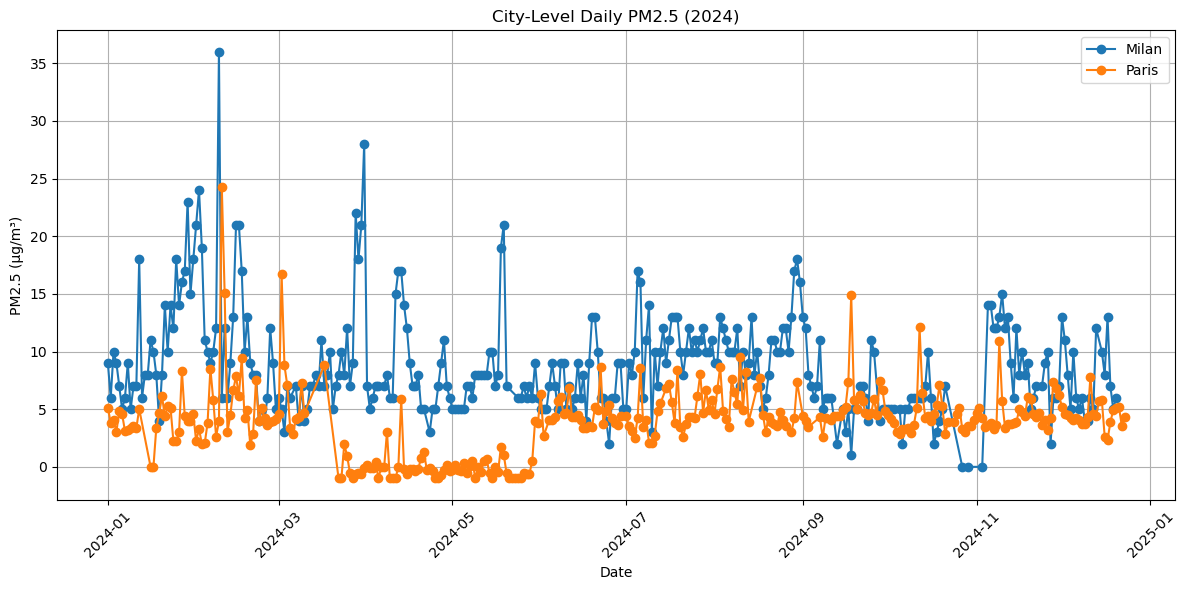

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city]
    plt.plot(
        city_data["date"],
        city_data["pm25_mean"],
        marker="o",
        linewidth=1.5,
        label=city
    )

plt.title("City-Level Daily PM2.5 (2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Daily PM2.5 Time Series

*Clear seasonality is visible in both cities.*

*Milan shows pronounced winter peaks (Jan–Feb) and intermittent spikes throughout the year.*

*Paris maintains lower baseline values, with short, isolated spikes.*

*Spring and early summer show cleaner air, especially in Paris.*

*Late autumn shows a gradual increase in both cities.*

*Interpretation: Seasonal factors strongly influence PM2.5 levels, with Milan consistently more affected.*

Boxplot — City-Level Distribution

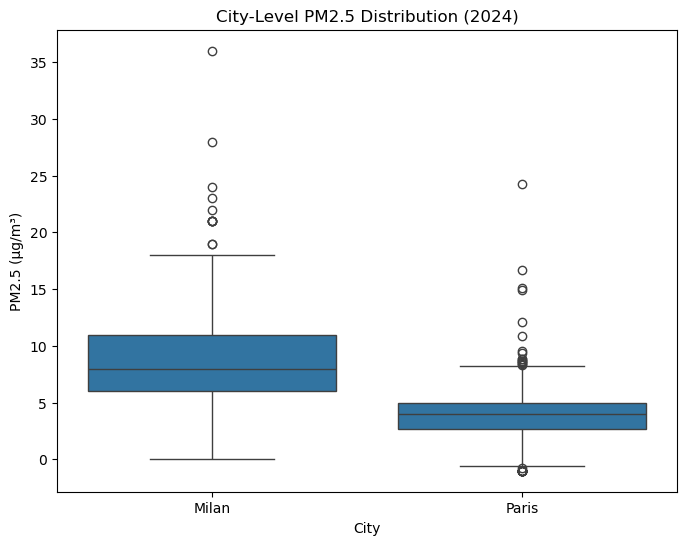

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="city", y="pm25_mean", data=df_city_daily)

plt.title("City-Level PM2.5 Distribution (2024)")
plt.xlabel("City")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


## PM2.5 Distribution (Boxplot)

*Median PM2.5 is higher in Milan than in Paris.*

*Milan’s interquartile range is wider, showing greater variability.*

*Milan has more and higher outliers, reaching above 30 µg/m³.*

*Paris has a tighter distribution, indicating more stable air quality.*

__Interpretation:__ *Milan not only has higher typical pollution levels but also more extreme and variable conditions.*

Histogram — City Comparison

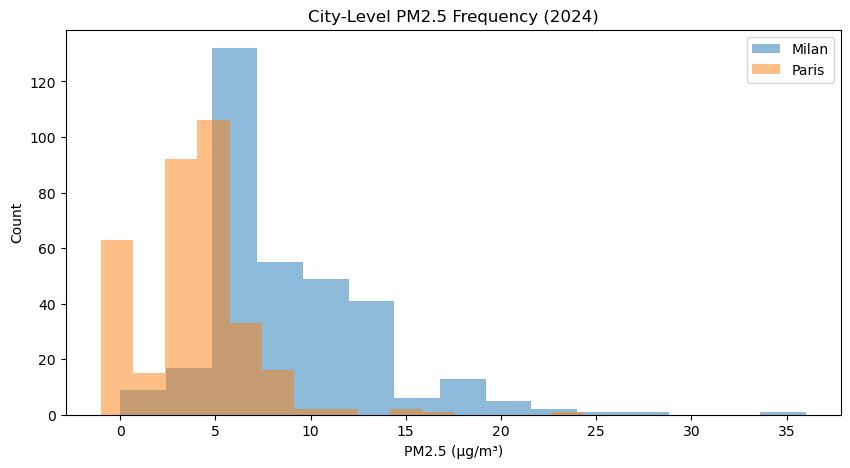

In [ ]:
plt.figure(figsize=(10,5))

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city]
    plt.hist(city_data["pm25_mean"], bins=15, alpha=0.5, label=city)

plt.title("City-Level PM2.5 Frequency (2024)")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Count")
plt.legend()
plt.show()


## PM2.5 Frequency (Histogram)

*Milan’s distribution is right-shifted, meaning higher PM2.5 values occur more frequently.*

*Milan shows a long tail toward high concentrations, indicating more pollution episodes.*

*Paris is concentrated at lower values (mostly ~2–6 µg/m³), with far fewer high-pollution days.*

*Overlap exists at low–moderate levels, but extreme values are largely driven by Milan.*

__Interpretation:__ Milan experiences higher and more frequent PM2.5 pollution events than Paris.

## GENERALIZED CONCLUSION

__The combined frequency, distribution, and time-series analyses reveal clear and persistent differences in PM2.5 air pollution between Milan and Paris in 2024. Milan consistently exhibits higher average concentrations, greater variability, and more frequent extreme pollution events, particularly during winter months. Paris, while experiencing occasional short-term spikes, generally maintains lower and more stable PM2.5 levels throughout the year. Both cities demonstrate strong seasonal patterns, with improved air quality during spring and early summer and deterioration in colder periods. Overall, the findings indicate a higher pollution burden and potential health risk in Milan, highlighting the need for targeted air quality management strategies in more pollution-prone urban environments.__

Manually Define Sensor IDs (INPUT)

In [ ]:
df_all = pd.concat([df_milan, df_paris], ignore_index=True)

df_all["date"] = df_all["datetime"].dt.date


In [ ]:
df_all["sensor_id"].nunique()


123

In [ ]:
sensor_days_coverage = (
    df_all
    .groupby(["city", "sensor_id"])["date"]
    .nunique()
    .reset_index(name="days_covered")
    .sort_values("days_covered", ascending=False)
)

sensor_days_coverage


,city,sensor_id,days_covered
114,Paris,7480205,333
28,Milan,7490833,332
112,Paris,7480203,332
110,Paris,7480201,331
75,Milan,7777172,330
...,...,...,...
107,Paris,5079023,28
103,Paris,5078877,28
93,Paris,4442231,28
122,Paris,11547735,28


In [ ]:
sensors_over_100_days = sensor_days_coverage[
    sensor_days_coverage["days_covered"] > 300
]

sensors_over_100_days


,city,sensor_id,days_covered
114,Paris,7480205,333
28,Milan,7490833,332
112,Paris,7480203,332
110,Paris,7480201,331
75,Milan,7777172,330
58,Milan,7774679,320
36,Milan,7773114,319
116,Paris,7798262,318
29,Milan,7531551,318
49,Milan,7774252,313


In [ ]:
# ---------------------------
# MANUAL SENSOR SELECTION
# ---------------------------

selected_sensors = [
    7480201,  
    7777172   
]


combine all data before filtering

In [ ]:
df_all = pd.concat([df_milan, df_paris], ignore_index=True)

df_all["datetime"] = pd.to_datetime(df_all["datetime"], utc=True)
df_all["date"] = df_all["datetime"].dt.date

df_all.head()


,datetime,value,unit,sensor_id,city,date
0,2024-01-01 23:00:00+00:00,7.0,None,5079445,Milan,2024-01-01
1,2024-01-01 23:00:00+00:00,11.0,None,5079458,Milan,2024-01-01
2,2024-01-01 23:00:00+00:00,12.0,None,5079452,Milan,2024-01-01
3,2024-01-01 23:00:00+00:00,11.8,None,7336787,Milan,2024-01-01
4,2024-01-01 23:00:00+00:00,14.0,None,6629241,Milan,2024-01-01


SANITY CHECK

In [ ]:
df_all["sensor_id"].unique()


array([ 5079445,  5079458,  5079452,  7336787,  6629241,  2142719,
        5078274,  6625728,  7490833,  7531551,  5078271,  5078267,
        5078294,  5078293,  5078264,  5078291,  5079014,  5078302,
        5078286,  5078814,  5078287,  5079210,  5078279,  5078270,
        5078729,  6661852,  7777632,  7777172,  7773744,  7775778,
        7774140,  7774785,  7774003,  7772850,  7774000,  7773552,
        7774775,  7773584,  7775178,  7775291,  7775409,  7775039,
        7774252,  7775618,  7774579,  7774679,  7775099,  7775760,
        7774426,  7774434,  7774365,  7772749,  7774309,  7773114,
        7774279,  7775024,  7773388,  7773043,  7773609,  7773115,
        7772744,  7774706,  7773796,  7774921,  7775963,  7774162,
        7775914,  7774841,  7773382,  7774544,  7773064,  7774326,
        7773017,  7780083,  7777523,  7852818,  7852816,    22634,
          22633,  7852822,    22605,    22636,  8622694,  9323264,
        9324553,  9323267,  9324555,  9323266,  9323263,  7480

FILTER TO MANUALLY SELECTED SENSORS

In [ ]:
df_manual = df_all[df_all["sensor_id"].isin(selected_sensors)].copy()

df_manual.head()



,datetime,value,unit,sensor_id,city,date
606,2024-01-25 23:00:00+00:00,30.0,None,7777172,Milan,2024-01-25
633,2024-01-26 23:00:00+00:00,28.0,None,7777172,Milan,2024-01-26
650,2024-01-27 23:00:00+00:00,31.0,None,7777172,Milan,2024-01-27
731,2024-01-28 23:00:00+00:00,25.0,None,7777172,Milan,2024-01-28
812,2024-01-29 23:00:00+00:00,34.0,None,7777172,Milan,2024-01-29


In [ ]:
df_manual.tail()

,datetime,value,unit,sensor_id,city,date
26031,2024-12-25 23:00:00+00:00,4.85,None,7480201,Paris,2024-12-25
26043,2024-12-26 23:00:00+00:00,18.20,None,7480201,Paris,2024-12-26
26049,2024-12-27 23:00:00+00:00,21.30,None,7480201,Paris,2024-12-27
26052,2024-12-28 23:00:00+00:00,19.10,None,7480201,Paris,2024-12-28
26061,2024-12-29 23:00:00+00:00,15.20,None,7480201,Paris,2024-12-29


SANITY CHECK

In [ ]:
df_manual["sensor_id"].unique()
df_manual.groupby(["city", "sensor_id"])["date"].agg(["min", "max", "nunique"])


,,min,max,nunique
city,sensor_id,,,
Milan,7777172,2024-01-25,2024-12-30,330
Paris,7480201,2024-01-01,2024-12-29,331


FILTER --ONLY 2024

In [ ]:
df_manual = df_manual[df_manual["datetime"].dt.year == 2024].copy()


VERIFY

In [ ]:
df_manual["datetime"].dt.year.value_counts()


datetime
2024    661
Name: count, dtype: int64

Define df_final

In [ ]:
df_final = (
    df_manual
    .sort_values(["city", "sensor_id", "datetime"])
    .drop_duplicates(subset=["city", "sensor_id", "date"])
    .reset_index(drop=True)
)

df_final.head()


,datetime,value,unit,sensor_id,city,date
0,2024-01-25 23:00:00+00:00,30.0,None,7777172,Milan,2024-01-25
1,2024-01-26 23:00:00+00:00,28.0,None,7777172,Milan,2024-01-26
2,2024-01-27 23:00:00+00:00,31.0,None,7777172,Milan,2024-01-27
3,2024-01-28 23:00:00+00:00,25.0,None,7777172,Milan,2024-01-28
4,2024-01-29 23:00:00+00:00,34.0,None,7777172,Milan,2024-01-29


DATA QUALITY CHECKS

In [ ]:
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   datetime   661 non-null    datetime64[ns, UTC]
 1   value      661 non-null    float64            
 2   unit       0 non-null      object             
 3   sensor_id  661 non-null    int64              
 4   city       661 non-null    object             
 5   date       661 non-null    object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(3)
memory usage: 31.1+ KB


In [ ]:
df_final.isnull().sum()


datetime       0
value          0
unit         661
sensor_id      0
city           0
date           0
dtype: int64

In [ ]:
df_final.duplicated(subset=["city", "sensor_id", "date"]).sum()


np.int64(0)

In [ ]:
df_final.groupby(["city", "sensor_id"])["date"].nunique()


city   sensor_id
Milan  7777172      330
Paris  7480201      331
Name: date, dtype: int64

DESCRIPTIVE STATISTICS

In [ ]:
df_final["value"].describe()


count    661.000000
mean       9.048899
std        6.988271
min       -1.000000
25%        4.870000
50%        8.000000
75%       12.000000
max       41.000000
Name: value, dtype: float64

BY CITY

In [ ]:
df_final.groupby("city")["value"].describe()


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Milan,330.0,11.815152,6.756675,3.0,7.000,10.0,14.000,41.0
Paris,331.0,6.291003,6.072591,-1.0,2.305,5.3,8.225,31.7


WHO HIGH POLLUTION DAYS

In [ ]:
WHO_PM25 = 25

high_pm_sensor = df_final[df_final["value"] > WHO_PM25]

high_pm_sensor_days = (
    high_pm_sensor
    .groupby(["city", "sensor_id"])["date"]
    .nunique()
)

high_pm_sensor_days


city   sensor_id
Milan  7777172      20
Paris  7480201       4
Name: date, dtype: int64

CITY LEVEL AGGERGATION

In [ ]:
df_city_daily = (
    df_final
    .groupby(["city", "date"], as_index=False)
    .agg(
        pm25_mean=("value", "mean"),
        sensors_used=("sensor_id", "nunique")
    )
)

df_city_daily.head()


,city,date,pm25_mean,sensors_used
0,Milan,2024-01-25,30.0,1
1,Milan,2024-01-26,28.0,1
2,Milan,2024-01-27,31.0,1
3,Milan,2024-01-28,25.0,1
4,Milan,2024-01-29,34.0,1


TIME SERIES PLOT CITY LEVEL

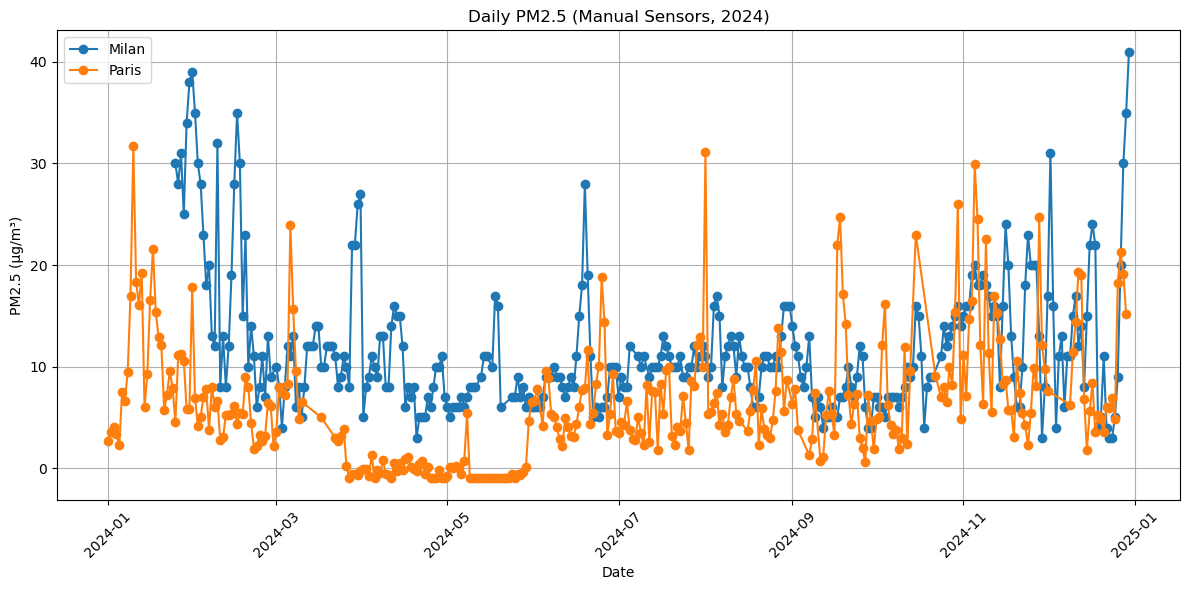

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city]
    plt.plot(
        city_data["date"],
        city_data["pm25_mean"],
        marker="o",
        linewidth=1.5,
        label=city
    )

plt.title("Daily PM2.5 (Manual Sensors, 2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Daily time series (raw data)

*Milan shows frequent spikes, especially in winter (Jan–Feb) and again in late autumn–early winter (Nov–Dec).*

*Paris has lower daily values overall, with occasional short-lived spikes.*

*Both cities display seasonality: worse air quality in colder months, cleaner in late spring and summer.*

BOXPLOT CITY LEVEL DISTRIBUTION

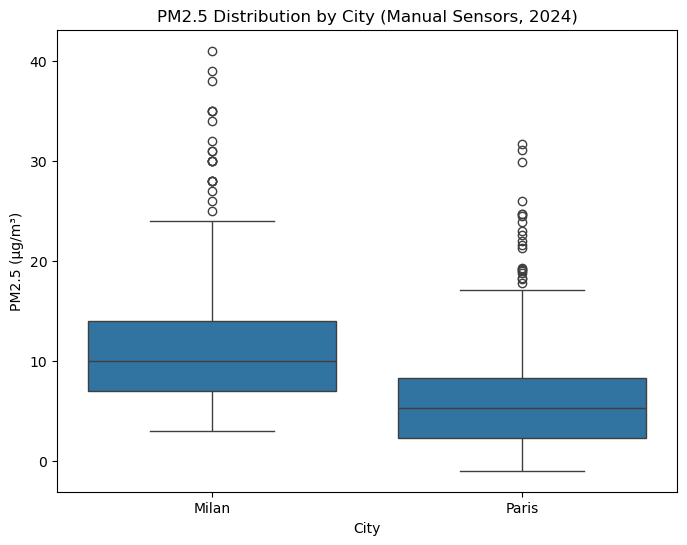

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x="city", y="pm25_mean", data=df_city_daily)

plt.title("PM2.5 Distribution by City (Manual Sensors, 2024)")
plt.xlabel("City")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


## Distribution (boxplot)

*Median PM2.5 is higher in Milan than Paris.*

*Milan’s distribution is wider, meaning more variability and more extreme pollution days.*

*Paris has a tighter spread, indicating more stable air quality.*

*High-end outliers are more common and more severe in Milan.*

WHO THRESHOLD + EXCEEDANCE

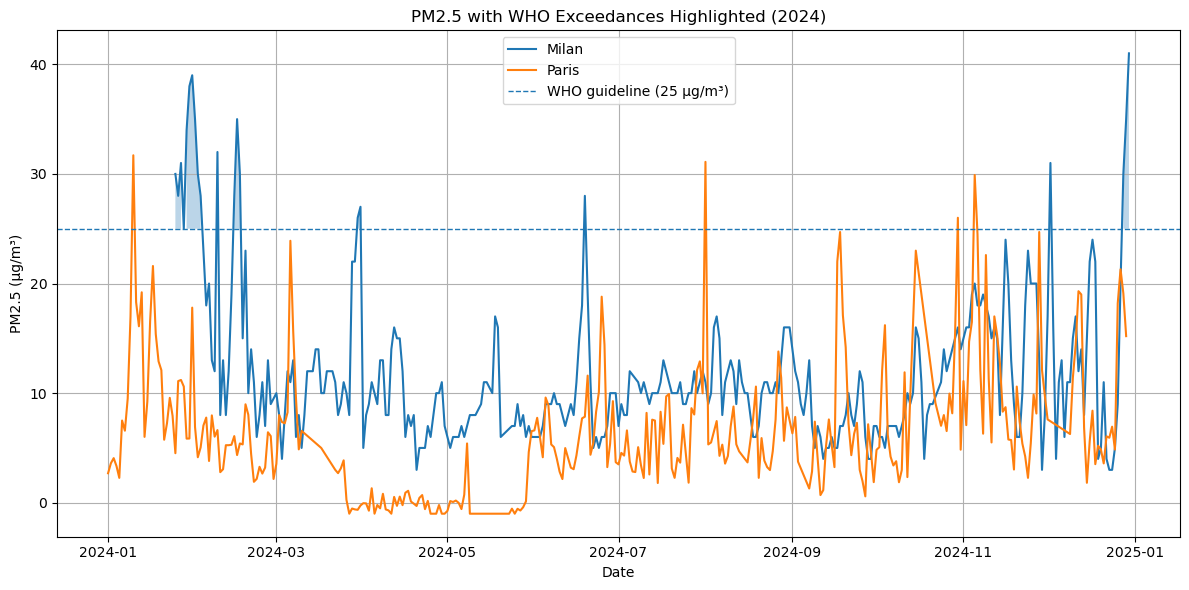

In [ ]:
WHO_PM25 = 25

plt.figure(figsize=(12,6))

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city]

    plt.plot(city_data["date"], city_data["pm25_mean"], label=city)

    plt.fill_between(
        city_data["date"],
        WHO_PM25,
        city_data["pm25_mean"],
        where=city_data["pm25_mean"] > WHO_PM25,
        alpha=0.3
    )

plt.axhline(WHO_PM25, linestyle="--", linewidth=1, label="WHO guideline (25 µg/m³)")

plt.title("PM2.5 with WHO Exceedances Highlighted (2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## WHO guideline exceedances (25 µg/m³)

*Milan exceeds the WHO guideline more often, especially in winter.*

*Paris exceeds the guideline less frequently and mostly during isolated events.*

*This suggests greater chronic exposure risk in Milan.*

AREA PLOT

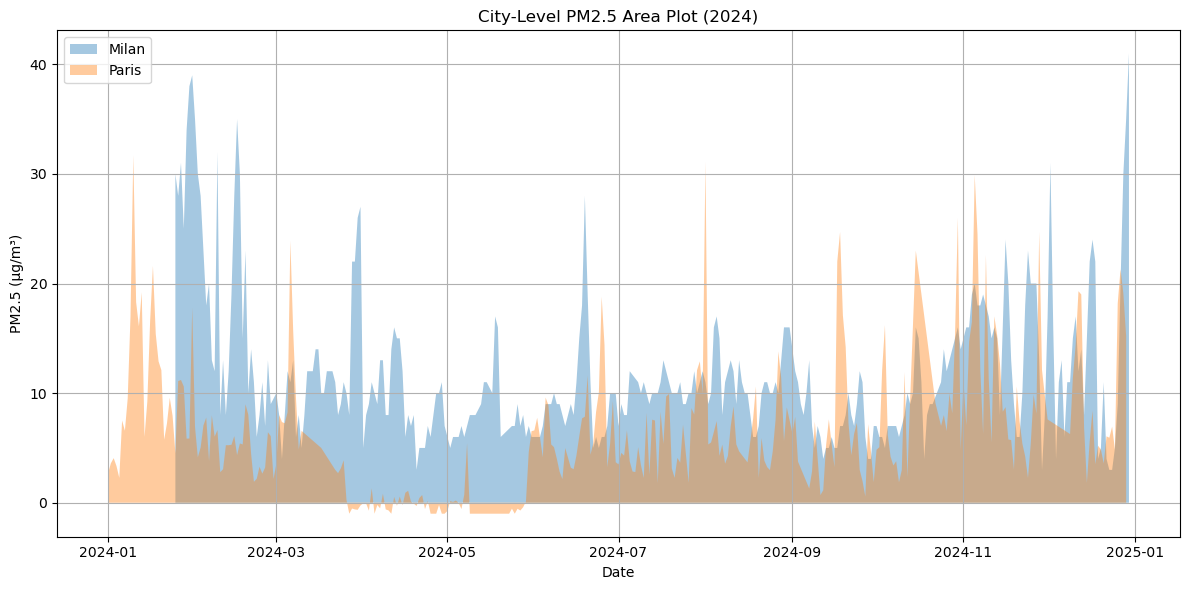

In [ ]:
plt.figure(figsize=(12,6))

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city]
    plt.fill_between(
        city_data["date"],
        city_data["pm25_mean"],
        alpha=0.4,
        label=city
    )

plt.title("City-Level PM2.5 Area Plot (2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Area plot (overall burden)

*The filled areas reinforce that Milan carries a higher cumulative PM2.5 burden throughout the year.*

*Paris contributes less total exposure, particularly during spring and early summer.*

ROLLING MEAN WITH SHADED VARIABILITY

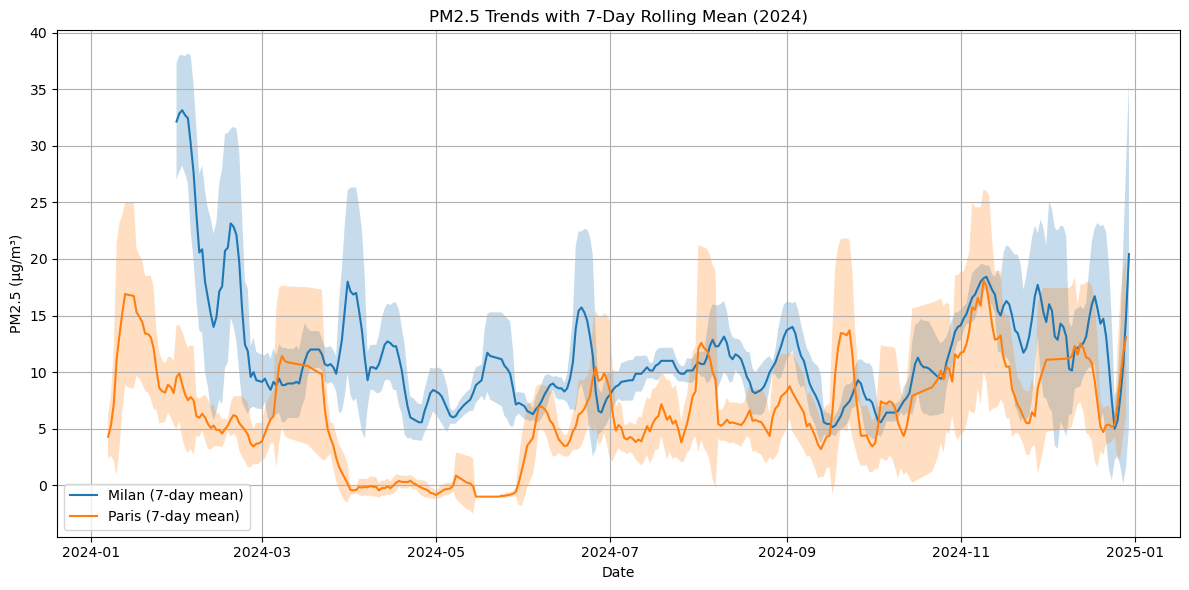

In [ ]:
plt.figure(figsize=(12,6))

WINDOW = 7  # 7-day rolling window

for city in df_city_daily["city"].unique():
    city_data = df_city_daily[df_city_daily["city"] == city].copy()
    
    city_data["rolling_mean"] = city_data["pm25_mean"].rolling(WINDOW).mean()
    city_data["rolling_std"] = city_data["pm25_mean"].rolling(WINDOW).std()

    plt.plot(city_data["date"], city_data["rolling_mean"], label=f"{city} (7-day mean)")
    
    plt.fill_between(
        city_data["date"],
        city_data["rolling_mean"] - city_data["rolling_std"],
        city_data["rolling_mean"] + city_data["rolling_std"],
        alpha=0.25
    )

plt.title("PM2.5 Trends with 7-Day Rolling Mean (2024)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7-day rolling mean (trend)

*Smoothing confirms that Milan maintains persistently higher background pollution.*

*Paris shows sharper short-term peaks but lower sustained levels.*

*Both cities improve in late spring, then worsen again toward winter.*

## CONCLUSION

__Overall, the analysis indicates clear differences in PM2.5 air pollution patterns between Milan and Paris over 2024. Milan consistently exhibits higher average concentrations, greater variability, and more frequent exceedances of the WHO air quality guideline, particularly during winter months, suggesting a higher and more sustained pollution burden. Paris, while experiencing occasional short-term pollution episodes, generally maintains lower and more stable PM2.5 levels throughout the year. Both cities display pronounced seasonal trends, with improved air quality in late spring and summer and deterioration in colder periods. These findings highlight the influence of seasonal and local factors on urban air quality and underscore the need for targeted mitigation strategies, especially in cities with persistently elevated pollution levels.__